## Supplementary Figure 3

## Helper codes: run below cells before any of the other cells. 

In [1]:
from pynwb import NWBHDF5IO
from scipy.io import savemat, loadmat
import mat73
import hdf5storage as st
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap

from sklearn.decomposition import PCA
from sklearn.manifold import Isomap, TSNE
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc

from scipy.sparse.linalg import eigsh
from scipy.stats import wilcoxon, kruskal, mannwhitneyu, sem, kstest, pearsonr, spearmanr
from scipy.optimize import curve_fit
from scipy.ndimage import maximum_filter1d

import seaborn as sns
from copy import deepcopy as dc
from statsmodels.stats.multitest import multipletests
# from statannot import add_stat_annotation

from itertools import combinations
import math
from umap import UMAP
from time import time

# # tell pandas to show all columns when we display a DataFrame
# pd.set_option("display.max_columns", None)

c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# loading variables

with open('resp_matrix_2p_ex2.pickle', 'rb') as f:
    resp_matrix_2p_ex = pickle.load(f)
    
    list_rate_ex = resp_matrix_2p_ex['list_rate_ex'].copy()
    list_slopes_all_att_loglog_dff = resp_matrix_2p_ex['list_slopes_all_att_loglog_dff'].copy()
    list_slopes_all_an_loglog_dff = resp_matrix_2p_ex['list_slopes_all_an_loglog_dff'].copy()
    list_slopes_all_att_loglog_deconv = resp_matrix_2p_ex['list_slopes_all_att_loglog_deconv'].copy()
    list_slopes_all_an_loglog_deconv = resp_matrix_2p_ex['list_slopes_all_an_loglog_deconv'].copy()

In [4]:
def compute_mean_var_trial(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1)
        trial_var = np.var(trial_rate, axis=1, ddof=1)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = pd.concat([trial_mean] * label_cnt_dict[trial_type], axis=1)
        list_trial_var[trial_ind] = pd.concat([trial_var] * label_cnt_dict[trial_type], axis=1)

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [5]:
def compute_mean_var_trial_collapse(label_cnt_dict, rate_sorted):    
    list_trial_mean = [[0]] * len(label_cnt_dict)
    list_trial_var = [[0]] * len(label_cnt_dict)

    for trial_ind, trial_type in enumerate(label_cnt_dict):
        
        trial_rate = np.array(rate_sorted.loc[:, trial_type])                
        trial_mean = np.mean(trial_rate, axis=1, dtype=np.longdouble)
        trial_var = np.var(trial_rate, axis=1, ddof=1, dtype=np.longdouble)

        trial_mean = pd.DataFrame(trial_mean, columns=[trial_type], index=rate_sorted.index)
        trial_var = pd.DataFrame(trial_var, columns=[trial_type], index=rate_sorted.index)
        list_trial_mean[trial_ind] = trial_mean.copy()
        list_trial_var[trial_ind] = trial_var.copy()

    rate_sorted_mean = pd.concat(list_trial_mean, axis=1)
    rate_sorted_var = pd.concat(list_trial_var, axis=1)

    return rate_sorted_mean, rate_sorted_var

In [6]:
# from pathlib import Path
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from copy import deepcopy as dc

# from oasis.functions import gen_data, gen_sinusoidal_data, deconvolve, estimate_parameters
# from oasis.plotting import simpleaxis
# from oasis.oasis_methods import oasisAR1, oasisAR2

In [7]:
# output_dir = '.'

In [8]:
# from allensdk.core.brain_observatory_cache import BrainObservatoryCache
# import pprint

# # This class uses a 'manifest' to keep track of downloaded data and metadata.  
# # All downloaded files will be stored relative to the directory holding the manifest
# # file.  If 'manifest_file' is a relative path (as it is below), it will be 
# # saved relative to your working directory.  It can also be an absolute path.
# boc =  BrainObservatoryCache(
#     manifest_file=str(Path(output_dir) / 'brain_observatory_manifest.json'))

# # Download a list of all targeted areas
# targeted_structures = boc.get_all_targeted_structures()
# print("all targeted structures: " + str(targeted_structures))

In [9]:
# import allensdk.brain_observatory.stimulus_info as stim_info

# # Find the experiment with the natural scenes stimulus
# exp = boc.get_ophys_experiments(cre_lines=['Emx1-IRES-Cre', 'Slc17a7-IRES2-Cre'], stimuli=[stim_info.NATURAL_SCENES], \
#                                 targeted_structures=['VISp'], reporter_lines=['Ai93(TITL-GCaMP6f)']) # all layers until 500 micrometers
# # pprint.pprint(exp)
# # print(len(exp))
# num_sess = len(exp)
# sess_ids = np.array([exp[sess_ind]['id'] for sess_ind in range(num_sess)])

# # deconvolved event
# list_events = np.empty(num_sess, dtype=object)
# for sess_ind, sess_id in enumerate(sess_ids):
#     # if sess_ind >= 15:
#         print(f'sess_ind {sess_ind}')
#         list_events[sess_ind] = boc.get_ophys_experiment_events(ophys_experiment_id=sess_id)

In [10]:
# # session data
# num_sess = len(exp)
# list_data_set = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     print(f'sess_ind {sess_ind}')
#     data_set = boc.get_ophys_experiment_data(exp[sess_ind]['id'])
#     list_data_set[sess_ind] = dc(data_set)

In [11]:
# # fluorescence trace and timestamps
# list_time_dff = np.empty(num_sess, dtype=object)
# for sess_ind, data_set in enumerate(list_data_set):
#     print(f'sess_ind {sess_ind}')
#     times, raw_traces = data_set.get_fluorescence_traces()
#     _, demixed_traces = data_set.get_demixed_traces()
#     _, neuropil_traces = data_set.get_neuropil_traces()
#     _, corrected_traces = data_set.get_corrected_fluorescence_traces()
#     _, dff_traces = data_set.get_dff_traces()
#     list_time_dff[sess_ind] = dc(dict(zip(['times', 'demixed_traces', 'neuropil_traces', 'corrected_traces', 'dff_traces'],
#                                           [times, demixed_traces, neuropil_traces, corrected_traces, dff_traces])))

In [12]:
# # extract natural scenes block
# list_df_ns = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     print(f'sess_ind {sess_ind}')

#     epoch_table = list_data_set[sess_ind].get_stimulus_epoch_table()
#     epoch_start = epoch_table[epoch_table['stimulus'] == 'natural_scenes']['start']
#     epoch_end = epoch_table[epoch_table['stimulus'] == 'natural_scenes']['end']
#     # print(epoch_start)

#     times = pd.Series(list_time_dff[sess_ind]['times']).copy()
#     cor_traces = pd.DataFrame(list_time_dff[sess_ind]['corrected_traces']).copy()
#     dff_traces = pd.DataFrame(list_time_dff[sess_ind]['dff_traces']).copy()
#     events = pd.DataFrame(list_events[sess_ind]).copy()
#     list_ns = dict(zip(['times', 'corrected_traces', 'dff_traces', 'events'], [[], [], [], []]))
#     for i in range(3): # 3 natural scenes blocks in total
#         list_ns['times'].append(times.iloc[epoch_start.iloc[i]:epoch_end.iloc[i]+1])
#         list_ns['corrected_traces'].append(cor_traces.iloc[:, epoch_start.iloc[i]:epoch_end.iloc[i]+1])
#         list_ns['dff_traces'].append(dff_traces.iloc[:, epoch_start.iloc[i]:epoch_end.iloc[i]+1])
#         list_ns['events'].append(events.iloc[:, epoch_start.iloc[i]:epoch_end.iloc[i]+1])
#     list_ns['times'] = pd.concat(list_ns['times'], axis=0)
#     list_ns['corrected_traces'] = pd.concat(list_ns['corrected_traces'], axis=1)
#     list_ns['dff_traces'] = pd.concat(list_ns['dff_traces'], axis=1)
#     list_ns['events'] = pd.concat(list_ns['events'], axis=1)
#     list_df_ns[sess_ind] = dc(list_ns)

In [13]:
# # reponse matrix (calcium fluorescence) (V1 excitatory neurons)
# num_sess = len(list_df_ns)
# list_rate_ex = np.empty(num_sess, dtype=object)
# for sess_ind in range(num_sess):
#     print(f'sess_ind {sess_ind}')

#     stim_table = list_data_set[sess_ind].get_stimulus_table('natural_scenes') # num_tot_trials x 3 (frame, start, end)
#     num_neurons = list_df_ns[sess_ind]['dff_traces'].shape[0]
#     num_tot_trials = stim_table.shape[0]
#     dict_ns = dict(zip(['Fcz', 'dFF', 'deconv'], [np.full((num_neurons, num_tot_trials), np.nan), np.full((num_neurons, num_tot_trials), np.nan), np.full((num_neurons, num_tot_trials), np.nan)]))
#     # dict_ns = dict(zip(['Fcz', 'dFF'], [np.full((num_neurons, num_tot_trials), np.nan), np.full((num_neurons, num_tot_trials), np.nan)]))
#     for trial in range(num_tot_trials):
#         start, end = stim_table.loc[trial, 'start'], stim_table.loc[trial, 'end']
#         dict_ns['Fcz'][:, trial] = list_df_ns[sess_ind]['corrected_traces'].loc[:, start:end+1].mean(axis=1) # average within a trial
#         dict_ns['dFF'][:, trial] = list_df_ns[sess_ind]['dff_traces'].loc[:, start:end+1].mean(axis=1)
#         dict_ns['deconv'][:, trial] = list_df_ns[sess_ind]['events'].loc[:, start:end+1].sum(axis=1) # sum

#     dict_ns['Fcz'] = (dict_ns['Fcz'] - np.mean(dict_ns['Fcz'], axis=1, keepdims=True)) / np.std(dict_ns['Fcz'], axis=1, ddof=1, keepdims=True) # z-score Fc
#     dict_ns['Fcz'] = pd.DataFrame(dict_ns['Fcz'], columns=stim_table.loc[:, 'frame']).copy()
#     dict_ns['dFF'] = pd.DataFrame(dict_ns['dFF'], columns=stim_table.loc[:, 'frame']).copy()
#     dict_ns['deconv'] = pd.DataFrame(dict_ns['deconv'], columns=stim_table.loc[:, 'frame']).copy()
#     list_rate_ex[sess_ind] = dc(dict_ns)

## Codes for figures

## Supplementary Figure 3a

In [14]:
# # Linear Fitting Slope across trial types (ABO Neuropixels all neurons) (loglog line) (dff)

# num_sess = 27
# act_mode = 'Fcz'
# act_mode = 'dFF'
# # act_mode = 'deconv'

# # Iterate over all sessions
# list_slopes_all_att_loglog_dff = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_ex):
# # for sess_ind in range(5):
#     # if sess_ind < 9:
#         print(f'session index: {sess_ind}')
        
#         rate = rate[act_mode].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for neu_ind in rate_sorted_mean_coll.index:

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, neu_ind] = popt.copy()
                
#         list_slopes_all_att_loglog_dff[sess_ind] = slopes.copy()

In [15]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (dff)

# # Iterate over all sessions
# num_sess = 27
# act_mode = 'Fcz'
# act_mode = 'dFF'
# # act_mode = 'deconv'

# list_slopes_all_an_loglog_dff = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_ex):
# # for sess_ind in range(5):
#     # if sess_ind < 9:
#         print(f'session index: {sess_ind}')
        
#         rate = rate[act_mode].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_all_an_loglog_dff[sess_ind] = slopes.copy()

across trial types Mean 0.52, Std 0.30, SEM 0.0042
across neurons Mean 0.85, Std 0.24, SEM 0.0042


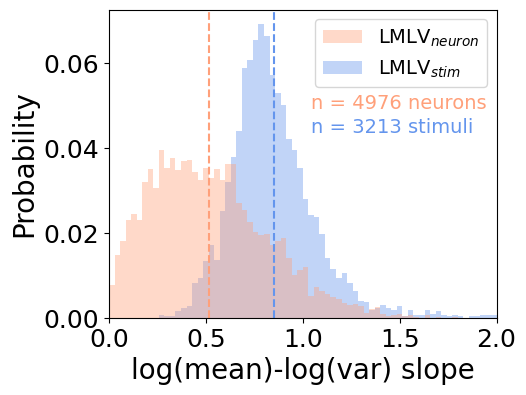

In [16]:
# loglog linear slope across trial types vs. across neurons (dff)
act_mode = 'dFF'
list_slopes_all_att_loglog_dff_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_dff) if slopes is not None])
list_slopes_all_an_loglog_dff_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_dff) if slopes is not None])

# histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
n_bins = 70
lower_bound, upper_bound = 0, 2

# across trial types
# weights = np.ones_like(list_slopes_all_att_loglog_dff_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_dff_flattened) / len(list_slopes_all_att_loglog_dff_flattened)
ax.hist(list_slopes_all_att_loglog_dff_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_slopes_all_att_loglog_dff_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_slopes_all_att_loglog_dff_flattened):.2f}, Std {np.std(list_slopes_all_att_loglog_dff_flattened, ddof=1):.2f}, SEM {sem(list_slopes_all_att_loglog_dff_flattened):.4f}')

# across neurons
# weights = np.ones_like(list_slopes_all_an_loglog_dff_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_dff_flattened) / len(list_slopes_all_an_loglog_dff_flattened)
ax.hist(list_slopes_all_an_loglog_dff_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_slopes_all_an_loglog_dff_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_slopes_all_an_loglog_dff_flattened):.2f}, Std {np.std(list_slopes_all_an_loglog_dff_flattened, ddof=1):.2f}, SEM {sem(list_slopes_all_an_loglog_dff_flattened):.4f}')

# ax.set_title(f'{act_mode}', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Number', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

ax.annotate(f'n = {list_slopes_all_att_loglog_dff_flattened.shape[0]} neurons', xy=(0.52, 0.68), xycoords='axes fraction', fontsize=14, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_dff_flattened.shape[0]} stimuli', xy=(0.52, 0.6), xycoords='axes fraction', fontsize=14, color='cornflowerblue')
ax.legend(loc='upper right', prop={'size': 14})
ax.set_xlim(0, 2)

# plt.savefig('code_images\\svg\\slope_histogram_asis_2cond_2p_' + act_mode + '.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\slope_histogram_asis_2cond_2p_' + act_mode + '.png', dpi=300, bbox_inches='tight')
plt.show()

## Supplementary Figure 3b

In [17]:
# # Linear Fitting Slope across trial types (ABO Neuropixels all neurons) (loglog line) (deconv)

# num_sess = 27
# act_mode = 'Fcz'
# act_mode = 'dFF'
# act_mode = 'deconv'

# # Iterate over all sessions
# list_slopes_all_att_loglog_deconv = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_ex):
# # for sess_ind in range(5):
#     # if sess_ind < 9:
#         print(f'session index: {sess_ind}')
        
#         rate = rate[act_mode].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all neurons
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[0]))
#         for neu_ind in rate_sorted_mean_coll.index:

#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[neu_ind] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[neu_ind, bool_mean_notzero].values).flatten().astype(np.float32), 1)
            
#             slopes[:, neu_ind] = popt.copy()
                
#         list_slopes_all_att_loglog_deconv[sess_ind] = slopes.copy()

In [18]:
# # Linear Fitting Slope across neurons (ABO Neuropixels all neurons) (loglog line) (deconv)

# # Iterate over all sessions
# num_sess = 27
# act_mode = 'Fcz'
# act_mode = 'dFF'
# act_mode = 'deconv'

# list_slopes_all_an_loglog_deconv = np.empty(num_sess, dtype=object)
# for sess_ind, rate in enumerate(list_rate_ex):
# # for sess_ind in range(5):
#     # if sess_ind < 9:
#         print(f'session index: {sess_ind}')
        
#         rate = rate[act_mode].sort_index(axis=1)
#         stm = rate.columns.copy()

#         # Create a counting dictionary for each stimulus
#         all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
#         stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

#         # Compute mean & variance for each stimulus
#         rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate)
#         rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate)

#         # Calculate and collect linear slopes for all stimuli
#         slopes = np.zeros((2, rate_sorted_mean_coll.shape[1]))
#         for trial_type_ind, trial_type in enumerate(rate_sorted_mean_coll.columns):
#             # loglog scale
#             bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > 0
#             popt = np.polyfit(np.log10(rate_sorted_mean.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), \
#                                 np.log10(rate_sorted_var.loc[bool_mean_notzero, trial_type].values).flatten().astype(np.float32), 1)
#             # popt = np.polyfit(np.log10(rate_sorted_mean.loc[:, trial_type].values).flatten().astype(np.float32), \
#             #                      np.log10(rate_sorted_var.loc[:, trial_type].values).flatten().astype(np.float32), 1)
            
#             slopes[:, trial_type_ind] = popt.copy()
        
#         list_slopes_all_an_loglog_deconv[sess_ind] = slopes.copy()

across trial types Mean 1.52, Std 0.15, SEM 0.0021
across neurons Mean 1.59, Std 0.09, SEM 0.0017


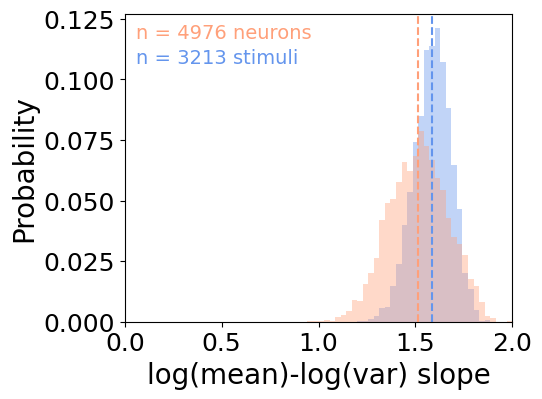

In [19]:
# loglog linear slope across trial types vs. across neurons (deconv)
act_mode = 'deconv'
list_slopes_all_att_loglog_deconv_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_att_loglog_deconv) if slopes is not None])
list_slopes_all_an_loglog_deconv_flattened = np.concatenate([slopes[0, :].flatten() for sess_ind, slopes in enumerate(list_slopes_all_an_loglog_deconv) if slopes is not None])

# histogram
fig, ax = plt.subplots(1, 1, figsize=(5, 4))
n_bins = 70
lower_bound, upper_bound = 0, 2

# across trial types
# weights = np.ones_like(list_slopes_all_att_loglog_deconv_flattened)
weights = np.ones_like(list_slopes_all_att_loglog_deconv_flattened) / len(list_slopes_all_att_loglog_deconv_flattened)
ax.hist(list_slopes_all_att_loglog_deconv_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='lightsalmon', alpha=0.4, label='LMLV$_{neuron}$', zorder=2)
ax.axvline(np.nanmean(list_slopes_all_att_loglog_deconv_flattened), color='lightsalmon', linestyle='--')
print(f'across trial types Mean {np.nanmean(list_slopes_all_att_loglog_deconv_flattened):.2f}, Std {np.std(list_slopes_all_att_loglog_deconv_flattened, ddof=1):.2f}, SEM {sem(list_slopes_all_att_loglog_deconv_flattened):.4f}')

# across neurons
# weights = np.ones_like(list_slopes_all_an_loglog_deconv_flattened)
weights = np.ones_like(list_slopes_all_an_loglog_deconv_flattened) / len(list_slopes_all_an_loglog_deconv_flattened)
ax.hist(list_slopes_all_an_loglog_deconv_flattened, bins=n_bins, range=(lower_bound, upper_bound), \
        weights=weights, color='cornflowerblue', alpha=0.4, label='LMLV$_{stim}$', zorder=1)
ax.axvline(np.nanmean(list_slopes_all_an_loglog_deconv_flattened), color='cornflowerblue', linestyle='--')
print(f'across neurons Mean {np.nanmean(list_slopes_all_an_loglog_deconv_flattened):.2f}, Std {np.std(list_slopes_all_an_loglog_deconv_flattened, ddof=1):.2f}, SEM {sem(list_slopes_all_an_loglog_deconv_flattened):.4f}')

# ax.set_title(f'{act_mode}', fontsize=20)
ax.set_xlabel('log(mean)-log(var) slope', fontsize=20)
ax.set_ylabel('Number', fontsize=18)
ax.set_ylabel('Probability', fontsize=20)
# ax.set_xticks([0, 0.5, 1, 1.5, 2])
# ax.set_yticks(np.arange(0, 0.21, 0.1))
ax.tick_params('both', labelsize=18)

ax.annotate(f'n = {list_slopes_all_att_loglog_deconv_flattened.shape[0]} neurons', xy=(0.03, 0.92), xycoords='axes fraction', fontsize=14, color='lightsalmon')
ax.annotate(f'n = {list_slopes_all_an_loglog_deconv_flattened.shape[0]} stimuli', xy=(0.03, 0.84), xycoords='axes fraction', fontsize=14, color='cornflowerblue')
# ax.legend(loc='upper left', prop={'size': 14})
ax.set_xlim(0, 2)

# print(np.sum(np.isnan(list_slopes_all_att_loglog_deconv_flattened)), np.sum(np.isnan(list_slopes_all_an_loglog_deconv_flattened)))

# plt.savefig('code_images\\svg\\slope_histogram_asis_2cond_2p_' + act_mode + '.svg', bbox_inches='tight')
# plt.savefig('code_images\\png\\slope_histogram_asis_2cond_2p_' + act_mode + '.png', dpi=300, bbox_inches='tight')
plt.show()

In [20]:
# with open('resp_matrix_2p_ex2.pickle', 'wb') as f:
#     pickle.dump({'tree_variables': ['list_rate_ex', 'list_slopes_all_att_loglog_dff', 'list_slopes_all_an_loglog_dff',
#                                     'list_slopes_all_att_loglog_deconv', 'list_slopes_all_an_loglog_deconv'],
#                  'list_rate_ex': list_rate_ex, 'list_slopes_all_att_loglog_dff': list_slopes_all_att_loglog_dff, 'list_slopes_all_an_loglog_dff': list_slopes_all_an_loglog_dff,
#                  'list_slopes_all_att_loglog_deconv': list_slopes_all_att_loglog_deconv, 'list_slopes_all_an_loglog_deconv': list_slopes_all_an_loglog_deconv}, f)

## Supplementary Figure 3c

Mean vs. Variance (ABO 2p)

session index: 7
184


c:\Users\USER\anaconda3\envs\allensdk_ep_mod\Lib\site-packages\pandas\core\internals\blocks.py:351: RuntimeWarning: invalid value encountered in log10
  result = func(self.values, **kwargs)


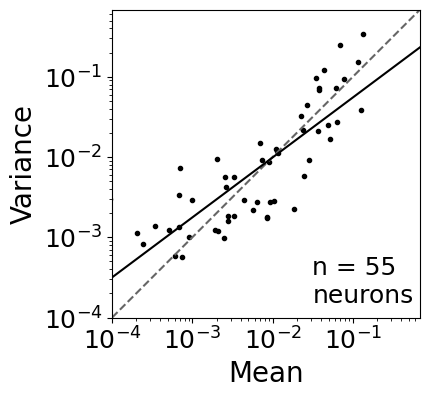

In [21]:
# Scatterplot & Model Lines across neurons (ABO 2p excitatory neurons)

print('Mean vs. Variance (ABO 2p)\n')

target_slope = 2
act_mode = 'Fcz'
act_mode = 'dFF'
list_slopes_all_an_loglog = list_slopes_all_an_loglog_dff

# Iterate over all sessions
for sess_ind, rate in enumerate(list_rate_ex):
    if sess_ind == 7:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate[act_mode].sort_index(axis=1)
        stm = rate_sorted.columns.copy()
        print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        # Convert 0 to NaN (verified that cases of mean=0 and var=0 coincide exactly)
        rate_sorted_mean_coll[rate_sorted_mean_coll == 0] = np.nan
        rate_sorted_var_coll[rate_sorted_var_coll == 0] = np.nan

        # calculate target variance
        var_estim_dr = pd.DataFrame(np.zeros((1, rate_sorted_var_coll.shape[1])), \
                                columns=rate_sorted_var_coll.columns)
        for trial_type in rate_sorted_var_coll.columns:
            var_estim_dr.loc[:, trial_type] = \
                np.nanmean(rate_sorted_var.loc[:, trial_type].values.flatten()) # nanmean
        # var_estim_dr = np.repeat(var_estim_dr, all_stm_counts, axis=1)
        # print(var_estim_dr)

        # offset = var_estim_dr.div(rate_sorted_var_coll.pow(target_slope/list_slopes_dr.iloc[0, :], axis=1).mean(axis=0))\
        # .mul(pow(10, target_slope * list_slopes_dr.iloc[1, :] / list_slopes_dr.iloc[0, :])) # collapsed
        offset = pow(10, (list_slopes_dr.iloc[0, :]-target_slope) * np.nanmean(np.log10(rate_sorted_mean_coll), axis=0) + list_slopes_dr.iloc[1, :])

        var_rs_noisy = \
            pow(10, np.log10(rate_sorted_var_coll).sub(list_slopes_dr.iloc[1, :], axis=1)\
                .div(list_slopes_dr.iloc[0, :], axis=1).mul(target_slope).add(np.log10(np.array(offset)), axis=1)) # collapsed
        var_rs_noisy = np.repeat(np.array(var_rs_noisy), all_stm_counts, axis=1)

        # Compute changed residual and add back to the mean
        rate_sorted_resid_dr = rate_sorted - rate_sorted_mean
        # rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
        #     .mul(np.sqrt(rate_sorted_mean)).mul(np.sqrt(FF_estim_dr), axis=1)
        rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
            .mul(np.sqrt(var_rs_noisy))
        # print(rate_resid_RRneuron_dr)
        rate_RRneuron_dr = rate_sorted_mean + rate_resid_RRneuron_dr
        rate_RRneuron_dr[rate_RRneuron_dr.isna()] = 0 # convert NaN to 0!

        # Compute mean and variance of slope-changed data
        rate_mean_RRneuron_coll, rate_var_RRneuron_coll = \
            compute_mean_var_trial_collapse(stm_cnt_dict, rate_RRneuron_dr)
        # FF_RRneuron = rate_var_RRneuron_dr.div(rate_mean_RRneuron_dr)
        # print(FF_RRneuron)
        # print(rate_var_RRneuron_dr)

        # convert NaN to 0
        rate_sorted_mean_coll[rate_sorted_mean_coll.isna()] = 0
        rate_sorted_var_coll[rate_sorted_var_coll.isna()] = 0

        # scatterplot & model lines
        
        # sample example stimuli
        rng = np.random.default_rng()
        rng = np.random.default_rng(sess_ind)
        n_examp_tt = 4
        examp_trial_type_inds = sorted(rng.choice(range(len(all_stm_unique)), n_examp_tt, replace=False))
        
        fig, axes = plt.subplots(1, 1, figsize=(4, 4))
        axes = np.array(axes).flatten()

        for trial_type_ind, trial_type in enumerate(all_stm_unique):
        # for trial_type_ind, trial_type in enumerate(all_stm_unique[examp_trial_type_inds]):

            if trial_type_ind == 73:
                trial_type_ind = 0
                thres = 0
                # mean_notzero = rate_sorted_mean_coll.loc[bool_mean_notzero, trial_type]
                # thres = np.nanpercentile(mean_notzero, 25)
                bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > thres

                # axes[trial_type_ind].set_title(f'trial_type_ind {trial_type_ind}', fontsize=20)
                axes[trial_type_ind].set_aspect('equal')

                axes[trial_type_ind].scatter(rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type], c='k', marker='.')

                # Range for x/y axes
                min_ = np.min([rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type]]) + 2**(-10) # add pseudo-value to avoid log 0
                max_ = np.max([rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type]]) * 2
                min_ = np.max([min_, np.max([thres, 1e-4])]) # rectify because 2p data has negative values

                axes[trial_type_ind].set_xlim(min_, max_)
                axes[trial_type_ind].set_ylim(min_, max_)
                axes[trial_type_ind].set_xscale('log')
                axes[trial_type_ind].set_yscale('log')

                axes[trial_type_ind].set_xlabel('Mean', fontsize=20)
                axes[trial_type_ind].set_ylabel('Variance', fontsize=20)
                axes[trial_type_ind].tick_params(axis='both', labelsize=18)

                # lines
                x = np.linspace(min_, max_)
                axes[trial_type_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

                axes[trial_type_ind].plot(x, pow(10, list_slopes_dr.loc[1, trial_type])*x**list_slopes_dr.loc[0, trial_type], color='k')
                # axes[trial_type_ind].annotate(f'y = {list_slopes_dr.loc[0, trial_type]:.2f}x + {list_slopes_dr.loc[1, trial_type]:.2f}', xy=(0.5, 0.15), xycoords='axes fraction', color='k', fontsize=18)
                # axes[trial_type_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.35, 0.05), xycoords='axes fraction', color='k', fontsize=18) # dff
                axes[trial_type_ind].annotate(f'n = {np.sum(bool_mean_notzero)}\nneurons', xy=(0.65, 0.05), xycoords='axes fraction', color='k', fontsize=18) # deconv

                # axes[trial_type_ind].plot(x, offset.loc[trial_type]*x**target_slope, color='orangered')
                # axes[trial_type_ind].annotate(f'y = {target_slope}x + {np.log10(offset.loc[trial_type]):.2f}', xy=(0.5, 0.1),  xycoords='axes fraction', color='orangered', fontsize=18)
                
        # plt.subplots_adjust(wspace=0.1, hspace=0.3)
        # plt.tight_layout()
        # # plt.savefig('code_images\\svg\\mvplot_asis_2p_' + act_mode + '.svg', bbox_inches='tight')
        # # plt.savefig('code_images\\png\\mvplot_asis_2p_' + act_mode + '.png', dpi=300, bbox_inches='tight')
        plt.show()

## Supplementary Figure 3d

Mean vs. Variance (ABO 2p)

session index: 7
184


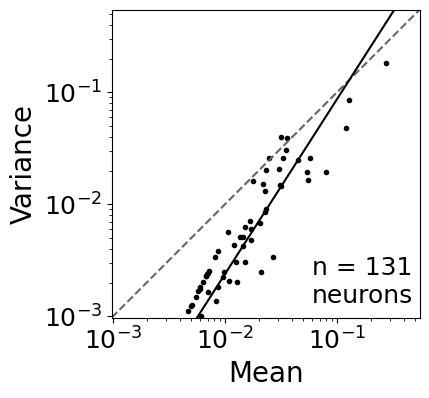

In [22]:
# Scatterplot & Model Lines across neurons (ABO 2p excitatory neurons)

print('Mean vs. Variance (ABO 2p)\n')

target_slope = 2
act_mode = 'deconv'
list_slopes_all_an_loglog = list_slopes_all_an_loglog_deconv

# Iterate over all sessions
for sess_ind, rate in enumerate(list_rate_ex):
    if sess_ind == 7:
        print(f'session index: {sess_ind}')
        
        rate_sorted = rate[act_mode].sort_index(axis=1)
        stm = rate_sorted.columns.copy()
        print(rate_sorted.shape[0])

        # Create a counting dictionary for each stimulus
        all_stm_unique, all_stm_counts = np.unique(stm, return_counts=True)
        stm_cnt_dict = dict(zip(all_stm_unique, all_stm_counts))

        # Compute mean & variance for each stimulus
        rate_sorted_mean, rate_sorted_var = compute_mean_var_trial(stm_cnt_dict, rate_sorted)
        rate_sorted_mean_coll, rate_sorted_var_coll = compute_mean_var_trial_collapse(stm_cnt_dict, rate_sorted)

        list_slopes_dr = pd.DataFrame(list_slopes_all_an_loglog[sess_ind], \
                                    columns=rate_sorted_mean_coll.columns).copy()

        # Convert 0 to NaN (verified that cases of mean=0 and var=0 coincide exactly)
        rate_sorted_mean_coll[rate_sorted_mean_coll == 0] = np.nan
        rate_sorted_var_coll[rate_sorted_var_coll == 0] = np.nan

        # calculate target variance
        var_estim_dr = pd.DataFrame(np.zeros((1, rate_sorted_var_coll.shape[1])), \
                                columns=rate_sorted_var_coll.columns)
        for trial_type in rate_sorted_var_coll.columns:
            var_estim_dr.loc[:, trial_type] = \
                np.nanmean(rate_sorted_var.loc[:, trial_type].values.flatten()) # nanmean
        # var_estim_dr = np.repeat(var_estim_dr, all_stm_counts, axis=1)
        # print(var_estim_dr)

        # offset = var_estim_dr.div(rate_sorted_var_coll.pow(target_slope/list_slopes_dr.iloc[0, :], axis=1).mean(axis=0))\
        # .mul(pow(10, target_slope * list_slopes_dr.iloc[1, :] / list_slopes_dr.iloc[0, :])) # collapsed
        offset = pow(10, (list_slopes_dr.iloc[0, :]-target_slope) * np.nanmean(np.log10(rate_sorted_mean_coll), axis=0) + list_slopes_dr.iloc[1, :])

        var_rs_noisy = \
            pow(10, np.log10(rate_sorted_var_coll).sub(list_slopes_dr.iloc[1, :], axis=1)\
                .div(list_slopes_dr.iloc[0, :], axis=1).mul(target_slope).add(np.log10(np.array(offset)), axis=1)) # collapsed
        var_rs_noisy = np.repeat(np.array(var_rs_noisy), all_stm_counts, axis=1)

        # Compute changed residual and add back to the mean
        rate_sorted_resid_dr = rate_sorted - rate_sorted_mean
        # rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
        #     .mul(np.sqrt(rate_sorted_mean)).mul(np.sqrt(FF_estim_dr), axis=1)
        rate_resid_RRneuron_dr = rate_sorted_resid_dr.div(np.sqrt(rate_sorted_var))\
            .mul(np.sqrt(var_rs_noisy))
        # print(rate_resid_RRneuron_dr)
        rate_RRneuron_dr = rate_sorted_mean + rate_resid_RRneuron_dr
        rate_RRneuron_dr[rate_RRneuron_dr.isna()] = 0 # convert NaN to 0!

        # Compute mean and variance of slope-changed data
        rate_mean_RRneuron_coll, rate_var_RRneuron_coll = \
            compute_mean_var_trial_collapse(stm_cnt_dict, rate_RRneuron_dr)
        # FF_RRneuron = rate_var_RRneuron_dr.div(rate_mean_RRneuron_dr)
        # print(FF_RRneuron)
        # print(rate_var_RRneuron_dr)

        # convert NaN to 0
        rate_sorted_mean_coll[rate_sorted_mean_coll.isna()] = 0
        rate_sorted_var_coll[rate_sorted_var_coll.isna()] = 0

        # scatterplot & model lines
        
        # sample example stimuli
        rng = np.random.default_rng()
        rng = np.random.default_rng(sess_ind)
        n_examp_tt = 4
        examp_trial_type_inds = sorted(rng.choice(range(len(all_stm_unique)), n_examp_tt, replace=False))
        
        fig, axes = plt.subplots(1, 1, figsize=(4, 4))
        axes = np.array(axes).flatten()

        for trial_type_ind, trial_type in enumerate(all_stm_unique):
        # for trial_type_ind, trial_type in enumerate(all_stm_unique[examp_trial_type_inds]):

            if trial_type_ind == 73:
                trial_type_ind = 0
                thres = 0
                # mean_notzero = rate_sorted_mean_coll.loc[bool_mean_notzero, trial_type]
                # thres = np.nanpercentile(mean_notzero, 25)
                bool_mean_notzero = rate_sorted_mean_coll.loc[:, trial_type] > thres

                # axes[trial_type_ind].set_title(f'trial_type_ind {trial_type_ind}', fontsize=20)
                axes[trial_type_ind].set_aspect('equal')

                axes[trial_type_ind].scatter(rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type], c='k', marker='.')

                # Range for x/y axes
                min_ = np.min([rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type]]) + 2**(-10) # add pseudo-value to avoid log 0
                max_ = np.max([rate_sorted_mean_coll.loc[:, trial_type], rate_sorted_var_coll.loc[:, trial_type]]) * 2
                min_ = np.max([min_, np.max([thres, 1e-4])]) # rectify because 2p data has negative values

                axes[trial_type_ind].set_xlim(min_, max_)
                axes[trial_type_ind].set_ylim(min_, max_)
                axes[trial_type_ind].set_xscale('log')
                axes[trial_type_ind].set_yscale('log')

                axes[trial_type_ind].set_xlabel('Mean', fontsize=20)
                axes[trial_type_ind].set_ylabel('Variance', fontsize=20)
                axes[trial_type_ind].tick_params(axis='both', labelsize=18)

                # lines
                x = np.linspace(min_, max_)
                axes[trial_type_ind].plot(x, x, color='0.4', linestyle='--') # y = x line

                axes[trial_type_ind].plot(x, pow(10, list_slopes_dr.loc[1, trial_type])*x**list_slopes_dr.loc[0, trial_type], color='k')
                # axes[trial_type_ind].annotate(f'y = {list_slopes_dr.loc[0, trial_type]:.2f}x + {list_slopes_dr.loc[1, trial_type]:.2f}', xy=(0.5, 0.15), xycoords='axes fraction', color='k', fontsize=18)
                # axes[trial_type_ind].annotate(f'n = {np.sum(bool_mean_notzero)} neurons', xy=(0.35, 0.05), xycoords='axes fraction', color='k', fontsize=18) # dff
                axes[trial_type_ind].annotate(f'n = {np.sum(bool_mean_notzero)}\nneurons', xy=(0.65, 0.05), xycoords='axes fraction', color='k', fontsize=18) # deconv

                # axes[trial_type_ind].plot(x, offset.loc[trial_type]*x**target_slope, color='orangered')
                # axes[trial_type_ind].annotate(f'y = {target_slope}x + {np.log10(offset.loc[trial_type]):.2f}', xy=(0.5, 0.1),  xycoords='axes fraction', color='orangered', fontsize=18)
                
        # plt.subplots_adjust(wspace=0.1, hspace=0.3)
        # plt.tight_layout()
        # # plt.savefig('code_images\\svg\\mvplot_asis_2p_' + act_mode + '.svg', bbox_inches='tight')
        # # plt.savefig('code_images\\png\\mvplot_asis_2p_' + act_mode + '.png', dpi=300, bbox_inches='tight')
        plt.show()